In [1]:
# Setup
import pandas as pd
import numpy as np
from scipy import stats
import plotly.express as px
from pathlib import Path

Path("charts").mkdir(exist_ok=True)
df = pd.read_csv("data/cleaned/jobs_cleaned.csv")
df_salary = df[df["Avg Salary"] > 0].copy()

print(f"Loaded {len(df)} jobs | {len(df_salary)} with salary data")
print(f"\nRoles:\n{df_salary['Role'].value_counts()}")

Loaded 929 jobs | 324 with salary data

Roles:
Role
Data Scientist               66
Machine Learning Engineer    60
Business Analyst             55
BI Analyst                   53
Data Engineer                49
Data Analyst                 41
Name: count, dtype: int64


In [2]:
# Hypothesis 1: Data Scientist vs Data Analyst Salary
ds = df_salary[df_salary["Role"] == "Data Scientist"]["Avg Salary"]
da = df_salary[df_salary["Role"] == "Data Analyst"]["Avg Salary"]

t_stat, p_value = stats.ttest_ind(ds, da)
u_stat, p_mann = stats.mannwhitneyu(ds, da, alternative="two-sided")

print(" Hypothesis 1: Data Scientist vs Data Analyst Salary")
print(f"  T-test     → t={t_stat:.3f}, p={p_value:.4f}")
print(f"  Mann-Whitney → u={u_stat:.1f}, p={p_mann:.4f}")
print(f"\n{' REJECT' if p_value < 0.05 else ' FAIL TO REJECT'} null hypothesis (α=0.05)")
print(f"{' Data Scientists earn SIGNIFICANTLY more!' if p_value < 0.05 else ' No significant salary difference found'}")

 Hypothesis 1: Data Scientist vs Data Analyst Salary
  T-test     → t=6.735, p=0.0000
  Mann-Whitney → u=2376.0, p=0.0000

 REJECT null hypothesis (α=0.05)
 Data Scientists earn SIGNIFICANTLY more!


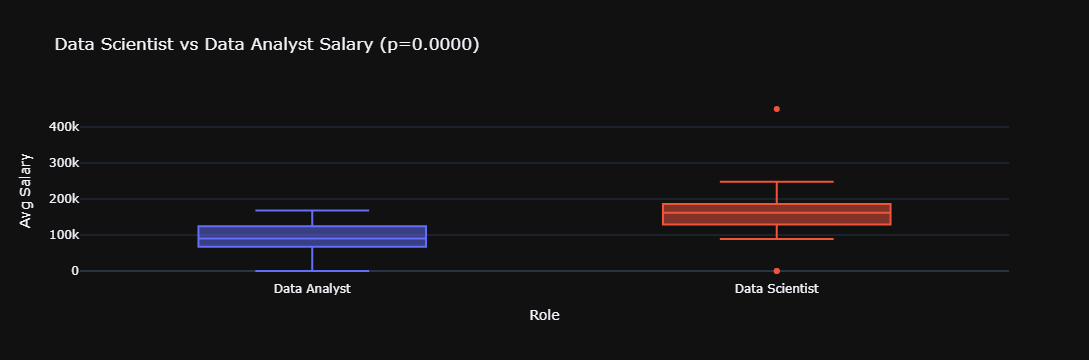

In [3]:
# Visualize H1
fig = px.box(
    df_salary[df_salary["Role"].isin(["Data Scientist","Data Analyst"])],
    x="Role", y="Avg Salary", color="Role",
    title=f"Data Scientist vs Data Analyst Salary (p={p_value:.4f})",
    template="plotly_dark").update_layout(showlegend=False)
fig.write_image("charts/13_h1_salary_comparison.png")
fig.show()

In [4]:
# Hypothesis 2: Remote vs Onsite Salary
remote = df_salary[df_salary["Job Is Remote"] == True]["Avg Salary"]
onsite = df_salary[df_salary["Job Is Remote"] == False]["Avg Salary"]

t_stat2, p_value2 = stats.ttest_ind(remote, onsite)
u_stat2, p_mann2 = stats.mannwhitneyu(remote, onsite, alternative="two-sided")

print(" Hypothesis 2: Remote vs Onsite Salary")
print(f"  Remote jobs: {len(remote)} | Avg: ${remote.mean():,.0f}")
print(f"  Onsite jobs: {len(onsite)} | Avg: ${onsite.mean():,.0f}")
print(f"\n  T-test     → t={t_stat2:.3f}, p={p_value2:.4f}")
print(f"  Mann-Whitney → u={u_stat2:.1f}, p={p_mann2:.4f}")
print(f"\n{' REJECT' if p_value2 < 0.05 else ' FAIL TO REJECT'} null hypothesis (α=0.05)")
print(f"{' Remote jobs pay SIGNIFICANTLY more!' if p_value2 < 0.05 else ' No significant salary difference found'}")

 Hypothesis 2: Remote vs Onsite Salary
  Remote jobs: 6 | Avg: $99,970
  Onsite jobs: 318 | Avg: $129,120

  T-test     → t=-0.913, p=0.3618
  Mann-Whitney → u=719.0, p=0.3022

 FAIL TO REJECT null hypothesis (α=0.05)
 No significant salary difference found


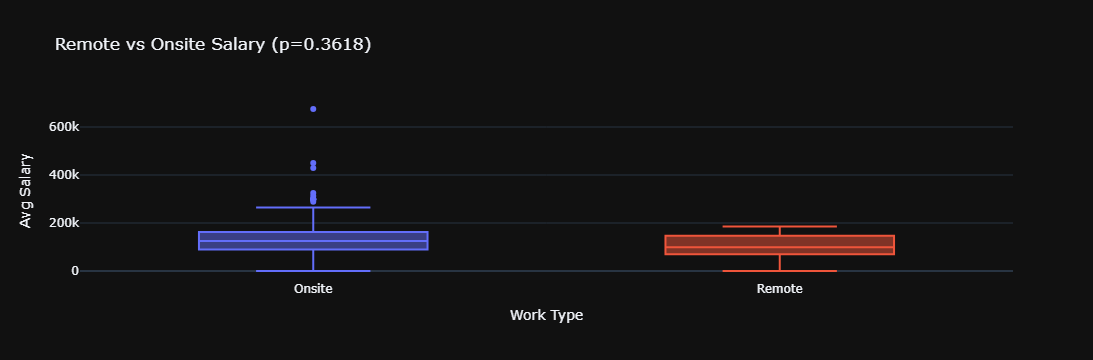

In [5]:
# Visualize H2
fig = px.box(
    df_salary.assign(**{"Work Type": df_salary["Job Is Remote"].map({True:"Remote", False:"Onsite"})}),
    x="Work Type", y="Avg Salary", color="Work Type",
    title=f"Remote vs Onsite Salary (p={p_value2:.4f})",
    template="plotly_dark").update_layout(showlegend=False)
fig.write_image("charts/14_h2_remote_salary.png")
fig.show()

In [8]:
# Cell 6 - Data Prep & Encoders
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import pickle

ml_df = df_salary[["Role", "Job City", "Job State", "Job Is Remote",
                    "Job Employment Type", "Avg Salary"]].copy()

encoders = {}
for col in ["Role", "Job City", "Job State", "Job Employment Type"]:
    encoders[col] = LabelEncoder().fit(ml_df[col])
    ml_df[col] = encoders[col].transform(ml_df[col])

X, y = ml_df.drop("Avg Salary", axis=1), ml_df["Avg Salary"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f" Train: {len(X_train)} | Test: {len(X_test)}")
print(f"Features: {X.columns.tolist()}")

 Train: 259 | Test: 65
Features: ['Role', 'Job City', 'Job State', 'Job Is Remote', 'Job Employment Type']


In [9]:
# Cell 7 - Compare Multiple Models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

models = {"Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
          "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=42),
          "XGBoost": XGBRegressor(n_estimators=100, random_state=42, verbosity=0)}

results = {name: {"MAE": mean_absolute_error(y_test, mdl.fit(X_train, y_train).predict(X_test)),
                  "RMSE": mean_squared_error(y_test, mdl.predict(X_test))**0.5,
                  "R2": r2_score(y_test, mdl.predict(X_test))}
           for name, mdl in models.items()}

[print(f"{n}: MAE=${v['MAE']:,.0f} | RMSE=${v['RMSE']:,.0f} | R²={v['R2']:.3f}") for n,v in results.items()]
best_model_name = min(results, key=lambda x: results[x]["MAE"])
print(f"\n Best Model: {best_model_name}")

Random Forest: MAE=$37,695 | RMSE=$53,252 | R²=0.325
Gradient Boosting: MAE=$37,332 | RMSE=$51,474 | R²=0.369
XGBoost: MAE=$41,128 | RMSE=$59,221 | R²=0.165

 Best Model: Gradient Boosting


In [10]:
# Cell 8 - Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV

param_grid = {"n_estimators": [100, 200],
              "max_depth": [3, 5],
              "learning_rate": [0.05, 0.1],
              "min_samples_split": [2, 5]}

grid_search = GridSearchCV(GradientBoostingRegressor(random_state=42),
                           param_grid, cv=5, scoring="neg_mean_absolute_error",
                           n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

print(f" Best Params: {grid_search.best_params_}")
print(f" Best CV MAE: ${-grid_search.best_score_:,.0f}")

Fitting 5 folds for each of 16 candidates, totalling 80 fits
 Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_split': 2, 'n_estimators': 100}
 Best CV MAE: $45,385


In [12]:
# Cell 9 - Final Model + Cross Validation
from sklearn.model_selection import cross_val_score

best_model = GradientBoostingRegressor(**grid_search.best_params_, random_state=42)
best_model.fit(X_train, y_train)

cv_scores = cross_val_score(best_model, X, y, cv=5, scoring="neg_mean_absolute_error")
preds_final = best_model.predict(X_test)

print(f" Cross Validation MAE: ${-cv_scores.mean():,.0f} ± ${cv_scores.std():,.0f}")
print(f" Test MAE:  ${mean_absolute_error(y_test, preds_final):,.0f}")
print(f" Test RMSE: ${mean_squared_error(y_test, preds_final)**0.5:,.0f}")
print(f" Test R²:   {r2_score(y_test, preds_final):.3f}")

 Cross Validation MAE: $46,508 ± $13,582
 Test MAE:  $34,885
 Test RMSE: $48,953
 Test R²:   0.429


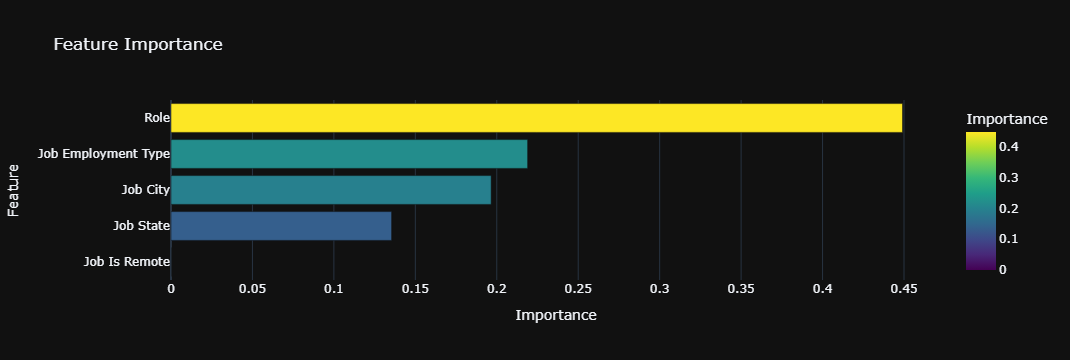

 Saved!


In [14]:
# Cell 10 - Feature Importance + Save Model
fig = px.bar(pd.DataFrame({"Feature": X.columns, "Importance": best_model.feature_importances_}).sort_values("Importance"),
             x="Importance", y="Feature", orientation="h", color="Importance",
             color_continuous_scale="viridis", title="Feature Importance", template="plotly_dark")
fig.write_image("charts/15_feature_importance.png"); fig.show()

Path("models").mkdir(exist_ok=True)
[pickle.dump(obj, open(f"models/{n}.pkl","wb")) for n,obj in {"salary_model":best_model,"encoders":encoders}.items()]
print(" Saved!")

In [16]:
# Cell 11 - Salary Predictor
def predict_salary(role, city, state, employment_type, is_remote=False):
    input_df = pd.DataFrame([{"Role": role, "Job City": city, "Job State": state,
                               "Job Is Remote": is_remote, "Job Employment Type": employment_type}])
    for col in ["Role", "Job City", "Job State", "Job Employment Type"]:
        input_df[col] = encoders[col].transform(input_df[col]) if input_df[col][0] in encoders[col].classes_ else 0
    return f" Predicted Salary: ${best_model.predict(input_df)[0]:,.0f}"

# Test it
# Test all 6 roles
for role in df_salary["Role"].unique():
    print(predict_salary(role, "New York", "New York", "Full-Time"))

 Predicted Salary: $130,170
 Predicted Salary: $186,079
 Predicted Salary: $130,170
 Predicted Salary: $170,754
 Predicted Salary: $209,710
 Predicted Salary: $130,170
